아래 내용이 필수적으로 들어가야 합니다.

- 다중선형회귀의 기본 가정 여섯가지
- 회귀 분석의 평가 방법
    - 시각화
    - 통계지표: 유의성 검정, 성능 평가
- 비선형 회귀 모델
    - 다항, 지수, 로그, 스플라인

# 선형회귀

## 1. 다중선형회귀의 수식적 이해
- 일반적인 식  
     > $y_i$ = $\beta_0$ + $\beta_1$ $X_{1i}$ + $\beta_2X_{2i}$ +...+ $\beta_kX_{ki}$ + $\varepsilon_i$
    - $y_i$ : i번째 종속 변수(우리가 관심 있는 값)
    - $X_{1i}, X_{2i}, ... , X_{ki}$ : i번째 y에 대한 여러 개의 설명변수(독립 변수)
    - $\beta_0$ : 절편, 설명변수(X)가 모두 0일 때 y의 값
    - $\beta_1, \beta_2, ..., \beta_k$ : 설명변수에 의한 회귀 계수 (각 변수 X의 영향력)
    - $\epsilon_i$  : 오차항

- -> 우리가 관심 있는 $y$에 대해, 영향을 줄 것 같은 여러 설명변수(독립변수)를 채택하여 선형적으로 식을 작성
- 상수항과 오차항을 제외한 식  
    > y=$w_0x_0$+$w_1x_1$+$\cdot\cdot\cdot$+$w_mx_m$=$\sum_{i=0}^mw_ix_i$=$w^Tx$
- -> 선형회귀식은 결국 **종속변수 y에 대한 독립변수들의 가중평균**이라고도 할 수 있음
- -> 설명변수에 가중치를 곱해 더함으로써 y를 얼마나 잘 **설명하는지**를 나타냄

    **그러나 선형회귀를 모든 상황에 쓸 수 있는 것은 아님!**

## 2. 다중선형회귀의 기본 가정 6가지
- 다음 가정을 만족하지 않으면 분석 결과의 신뢰성이 떨어짐
- 심각한 경우, 분석 자체가 불가능
> #### 가정 1 - 선형성(Linearity)
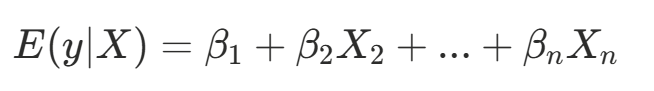
- 종속변수와 설명변수 간의 관계가 선형적이어야 한다는 가정
- 위 식의 형태를 따라야 함

> #### 가정 2 - 독립성(independent)
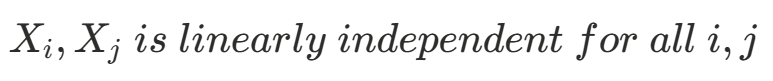
- 각각의 설명변수가 서로 선형독립적이어야 한다는 가정
- 선형독립적이지 않은 경우 다중공선성이 있다고 함
    - 다중공선성: 독립 변수들이 서로 강한 상관관계를 가져서, 어떤 변수가 종속 변수에 가장 큰 영향을 주는지를 알 수 없는 상태

> #### 가정 3 - 오차항의 평균은 0이다(0에 가까워야 한다)
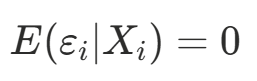
- 오차항의 평균은 0이거나 0에 가까워야 한다는 가정
- 오차항($\epsilon$): 실제 값과 예측 값 사이의 차이
- **White noise(백색 잡음)**
    - 특정 패턴 없이 랜덤하게 변하는 신호
    - 0이 아닌 만큼 부족하게/넘치게 예측

> #### 가정 4 - 등분산성(Homoscedasticity)
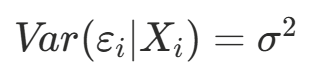
- 오차항($\epsilon$)의 분산($\sigma^2$)이 일정해야한다는 가정
- 그렇지 않을 경우, 이분산성(heteroscedasticity)
    - 횡단면 자료에서 주로 나타남
    - 등분산성 가정을 만족하지 않으면, 모델의 예측이 일부 구간에서는 매우 정확하지만, 일부 구간에서는 오차가 매우 커질 수 있음
    <details>
    
    1. 잔차의 도표화

    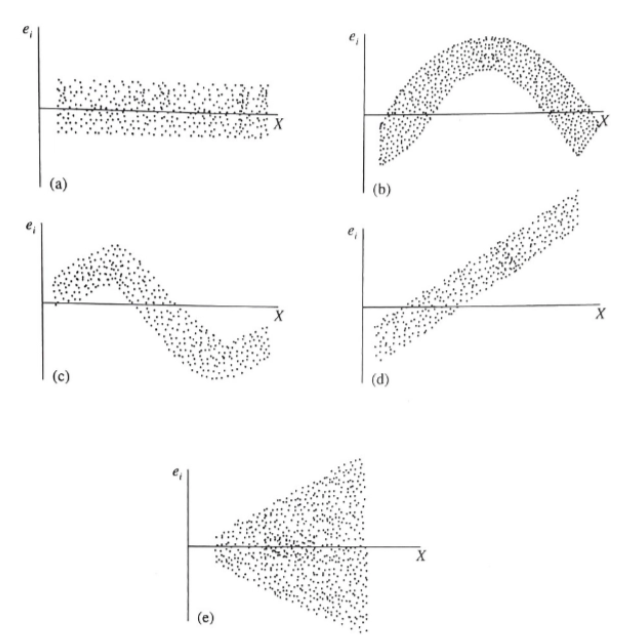  
    
    2. 검정 (Brown-Forsythe, Breusch-Pagan)
    <summary> 등분산성을 알아보는 법

> #### 가정5 - 오차항은 자기상관되어 있지 않다(Non-autocorrelation)
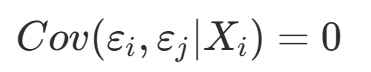
- 오차항의 공분산(Cov)은 항상 0이어야 된다는 가정
    <details>
    
    - 두 변수 간의 상관된 정보를 나타내는 지표
    - 두 변수가 어떻게 함께 변하는지 측정하는 값
    - Cov(X,Y)에 대해,
        - Cov(X,Y)>0: X가 증가하면 Y도 **증가**하는 관계(양의 상관관계)
        - Cov(X,Y)<0: X가 증가하면 Y는 **감소**하는 관계(음의 상관관계)
        - Cov(X,Y)=0: X와 Y는 **독립적**인 관계
    <summary> 공분산이란?
- 오차항의 공분산이 0이 아닌 경우, 자기상관(autocorrelation)이 있다고 함
    - **자기상관**: 한 변수의 **현재 값이 과거 값과 상관관계**를 가지는 현상
    - 특히 **시계열 자료**에서 많이 나타남
    - 모델이 데이터를 랜덤하게 예측하는 것이 아니라, **이전 데이터의 패턴을 학습**하여 **반복적인 오류**를 만들어 낼 가능성이 높음
- 확인방법
    1. 더빈-왓슨 검정(Durbin-Watson Test)
    2. ACF, PACF 함수 찍어보기

> #### 가정6(선택) - 정규성(Normality)
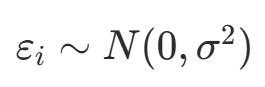
- 오차항이 정규분포를 따른다는 가정
- 위배되어도 다중선형회귀분석 결과의 큰 영향을 주지 않음
<details> <summary>오차항이 정규분포를 따라야 하는 이유</summary>

 - 회귀계수들의 신뢰구간과 p-value를 계산할 때 사용되는 공식이 오차항이 정규분포를 따른다고 가정하고 만들어졌기 때문 </details> <details><summary>정규성을 알아보는 법</summary>
 
 1. 샤피로-윌크 검정 (Shapiro-Wilk Test)

 2. 자퀴-베라 검정 (Jarque-Bera Test)

 3. Q-Q plot 찍어보기 </details>

> ##### 회귀 분석 전 vs. 후 검증해야 할 가정 정리
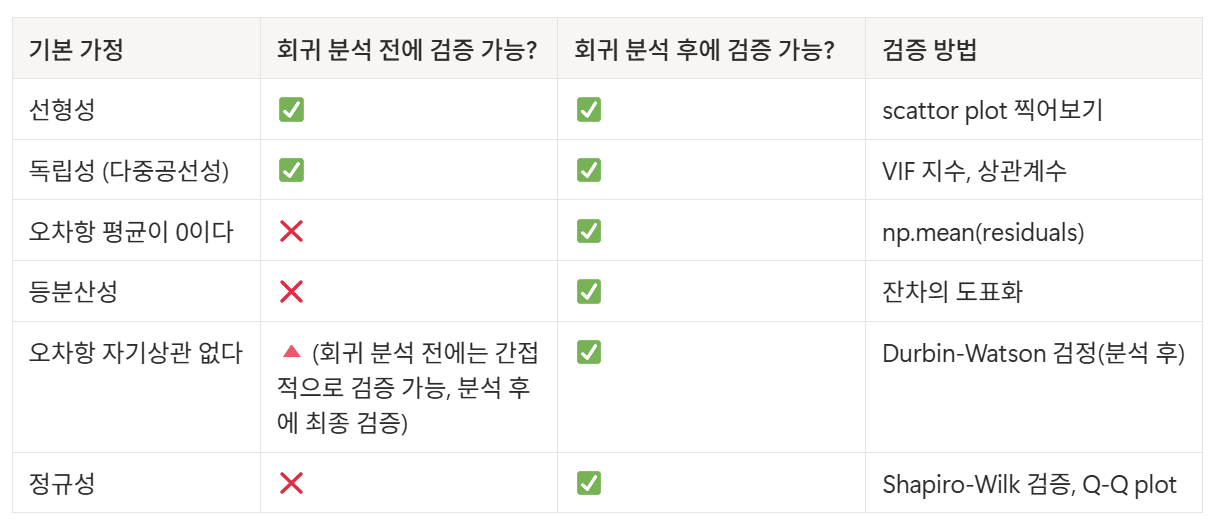
- 위 표의 기준: '오차항에 대한 가정인가?'
- 회귀식은 보통 $y$ = $\beta_0$ + $\beta_1X$ + $\epsilon$으로 표현되는데, 여기서 오차항 $\epsilon$은 모델 학습 후에 정해지는 정답과 예측 간의 차이
- 모델 학습 전에는 $X$와 $y$만 가지고 있기 때문에 오차항을 계산할 수 있는 근거가 없음
- 모델 학습(분석) 후에 검증을 진행하였는데, 가정에 위배된다면 **다시 해야 함**

## 3. 회귀분석 평가 방법
- 회귀분석 결과의 유효성을 평가하긴 위해선 회귀선을 데이터와 함께 **시각화**하거나 **통계지표**를 사용
> #### 1. 시각화
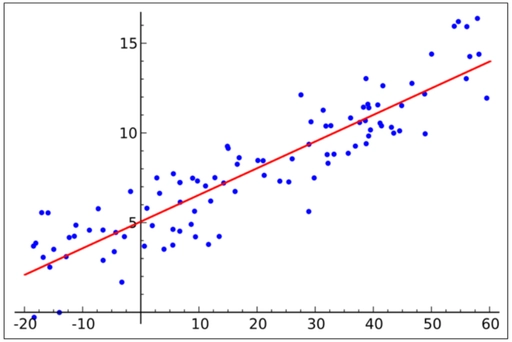
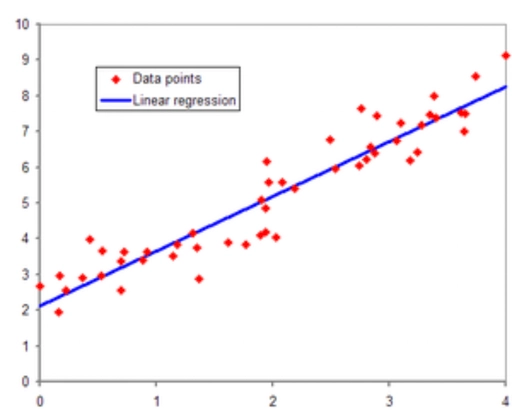

- 회귀선이 데이터 전반을 잘 요약하는 모습
- But, 어느 회귀선이 해당 데이터를 더 잘 요약하는지 비교가 어려움
- 통계지표를 사용하여 객관적 비교
> #### 2. 통계지표

>> 1. 모델 유의성 검정

- F-statistic, Prob(F-statistic)
    - 회귀 모델이 유의미한지 검정하는 지표
        - 귀무가설 $H_0$: 모든 회귀 계수가 0이다(독립 변수들이 종속 변수들과 관계가 없다).
        - 대립가설 $H_1$: 적어도 하나의 회귀 계수는 0이 아니다.(독립 변수 중 하나 이상이 종속 변수에 영향을 준다)
    - F-statistic의 값이 클수록 모델이 통계적으로 유의미하다는 것을 의미
    - Prob(F-statistic) (F-통계량의 유의확률)은 F-statistic의 p-value로, Prob가 0.05보다 작다면, 귀무가설을 기각
-  T-statistic, Prob(T-statistic)
    - T-statistic (T-통계량)은 각 독립변수가 종속변수 y에 유의미한 영향을 미치는지 판단하는 지표
        - 귀무가설 $H_0$: 해당 변수의 회귀 계수가 0이다. (이 변수는 종속 변수에 영향을 미치지 않는다)
        - 대립가설 $H_1$: 해당 변수의 회귀 계수는 0이 아니다. (이 변수는 종속 변수에 유의미한 영향을 준다)
    - P>|T-statistic| (p-value, T-통계량의 유의확률)를 기준으로 가설 검정을 수행
        - x1: P>|t| 값이 0.000이므로 0.05보다 작다 → **x1**이 종속 변수에 **유의미한 영향**을 미친다.
        - x2: P>|t| 값이 0.031이므로 0.05보다 작다 → **x2**가 종속 변수에 **유의미한 영향**을 미친다
        - x3: P>|t| 값이 0.569이므로 0.05보다 크다 → **x3**가 종속 변수에 **유의미한 영향을 미치지 않는다.**
>> 2. 모델의 성능 평가

>>> - 결정계수

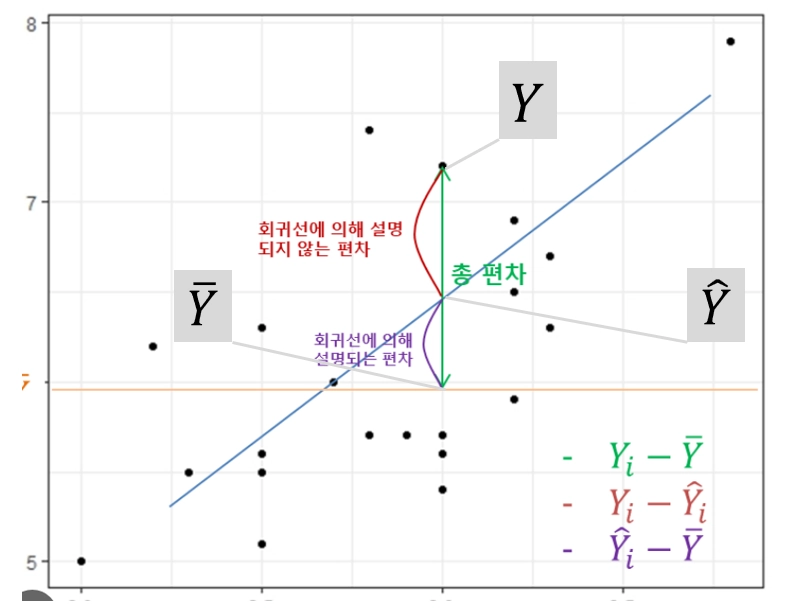
- $\bar{Y}$: 평균 / $\hat{Y}$: 예측 값 / $Y$: 실제 값
- 결정계수 $R^2$는 회귀 모델이 종속 변수의 전체 변동성을 얼마나 잘 설명하는지 나타내는 지표
- 즉, 모델이 데이터를 얼마나 잘 설명하는지 측정
- 단순히 평균값으로 데이터를 예측했을 때보다, 모델을 활용했을 때 오차가 얼마나 줄어드는지를 수치화
- 위 그림에서는 노란색 선으로 표시된 전체 데이터가 평균

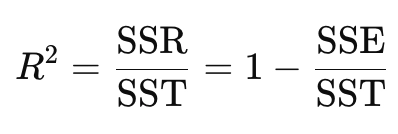
- **SST :** 평균($\bar{Y}$)으로 예측했을 때의 총 오차 (우리가 극복해야 할 전체 변동성)
- **SSE:** 모델($\hat{Y}$)이 예측하고도 여전히 남은 오차 (모델의 한계)
- **SSR:** 평균에 비해 **Regression** 모델이 얼마나 더 잘 맞혔는지 (모델의 성과)
- $0$ ≤ $R^2$ ≤ $1$
- 1에 가까울수록, SSR과 SST의 값이 비슷해 지고, SSE는 0에 가까워짐 -> **"모델이 데이터를 잘 설명한다."**
- R-squared 값이 0이면, 데이터들의 평균을 구한 것과 모델로 예측을 한 것이 동일한 것 -> **"모델이 데이터를 전혀 설명하지 못한다."**

>>> - 조정된 결정 계수 (Adjusted R-squared, Adjusted $R^2$)
- $R^2$는 독립 변수의 개수가 증가하면 증가할수록 자연스레 증가
- 따라서 변수의 개수 증가에 덜 민감하도록 조정한 지표가  Adjusted $R^2$
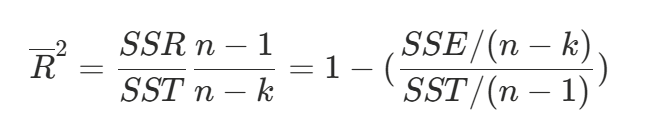
- ($n$: 샘플 수, $k$: 독립변수의 개수)
- 변수의 개수(k)가 증가하면 전체 값은 감소 -> 변수 개수에 따른 설명력 추가 부분을 상쇄하는 효과
- $\frac{SSE}{n-k}$  vs  $\frac{SST}{n-1}$
    - 변수를 추가했을 때, **SSE(회귀선에 의해 설명되지 않는 편차)가 충분히 감소**하면, $\frac{SSE}{n-k}$가 작아져서 **R-square 값이 증가**
    - 변수를 추가했을 때, SSE가 거의 그대로라면(데이터와 관련성이 없는 변수를 추가하면), $\frac{SSE}{n-k}$에서 SSE는 동일하고 n-k만 감소하므로 $\frac{SSE/(n-k)}{SST/(n-1)}$에서 분자 값이 커짐
    - 따라서 adjusted R-square 값은 감소 (1에서 더 큰 값을 빼니까)
- 식에 (n-1/n-k)을 곱한 것을 변수의 개수(k)에 따른 penalty를 부여했다고 표현

>>> - AIC, BIC(SC)

두 지표 모두 정보 기준(information criteria)이라고도 불리며, 값이 낮을수록 좋다고 평가
- AIC = **Akaike information criterion**
    - BIC에 비해 복잡성에 대한 패널티가 비교적 작음
- BIC(SC): SC = **Schwarz Criterion,** BIC = **Bayesian Information Criterion**
    - AIC보다 더 엄격한 기준으로, 데이터의 양(n)에 따라 더 강한 패널티를 부과




# 비선형회귀

## 1. 다항식 회귀 모델 (Polynomial Regression Model)
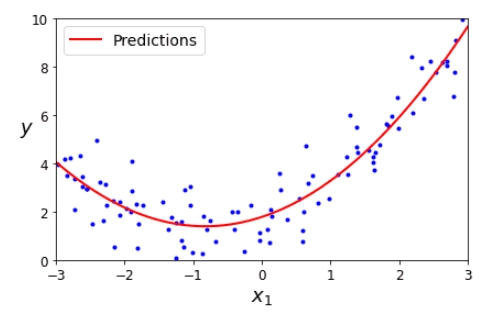
- 기존의 선형 회귀: $Y=a+bX$
- 다항식 회귀 모델: $Y=a+bX+cX^2+dX^3+\cdot\cdot\cdot$의 형태로, **독립 변수에 거듭제곱 항**을 추가하여 데이터의 **곡선적(비선형적) 특성을 모델링**
- 사용 방법
    1. 기존의 선형 모델 $Y = a + bX$에 대해 $cX^2, dX^3$ 등을 포함하여 모델을 확장
    2. 확장한 상태에 선형 회귀를 적용
<details>
<summary><strong>code</strong></summary>

1. 기존 변수들을 다항식으로 변환

`from sklearn.preprocessing import PolynomialFeatures`

`poly = PolynomialFeatures(degree=2, include_bias=False)`   
`X_poly = poly.fit_transform(X)`


2. 선형회귀 적용

- **statsmodels (sm.OLS)**

`import statsmodels.api as sm`

`X_poly = sm.add_constant(X_poly)`  
`model = sm.OLS(Y, X_poly).fit()`  
`Y_pred = model.predict(X_poly)`

- **sklearn (LinearRegression)**

`from sklearn.linear_model import LinearRegression`

`model = LinearRegression()`  
`model.fit(X_poly, Y)`  
`Y_pred = model.predict(X_poly)`

</details>

- 장단점
    - 장점: 선형 모델보다 데이터에 더 잘 fit되는 곡선 생성 가능  
    - 단점: feature가 많아질수록 overfitting 위험 증가  
  → Ridge / Lasso 같은 규제 기법으로 완화 가능

- **적합한 상황**
    - 관계가 직선적이지 않고 **곡선을 그리는 데이터 패턴**에서 유용
    - **성장률, 감소율** 등이 시간에 따라 변화하는 속도가 다른 경우 유용

## 2. 지수 회귀 모델 (Exponential model)
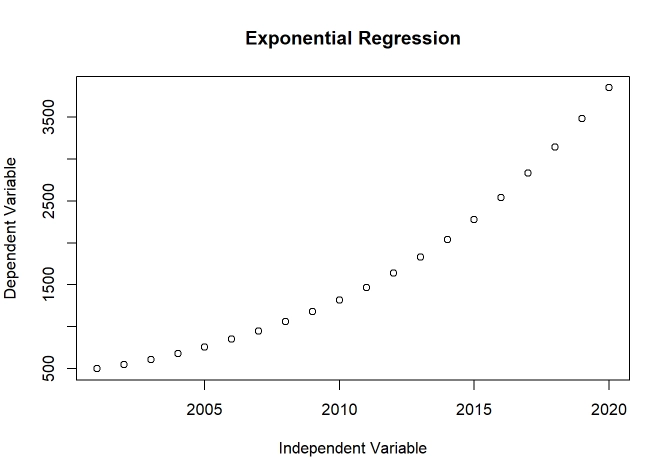
- 종속 변수가 지수적으로 변화하는 관계를 모델링할 때 사용할 수 있음
- 사용 방법
    1. 종속 변수 Y에 로그함수를 적용
    2. 로그 변환된 Y와 기존의 독립변수 X에 대해 선형 회귀 적용 -> 모델이 ln Y(로그 변환된 Y)와 X의 선형 관계를 학습
    3. Y값을 예측 시, 모델이 예측한 Y값에 지수함수$(e^x)$를 적용하여 로그 변환하기 전 Y로 변형

<details>
<summary><strong>code</strong></summary>

`import numpy as np`  
`import matplotlib.pyplot as plt`  
`import statsmodels.api as sm`

- 지수함수 형태의 임의의 데이터 생성  
`np.random.seed(42)`  
`X = np.linspace(1, 10, 20).reshape(-1, 1)`  
`Y = 2 * np.exp(0.8 * X).flatten() + np.random.normal(0, 10, X.shape[0])`   

- 종속변수 Y에 자연 로그 변환  
`log_Y = np.log(Y) # log_Y: 로그 변환된 Y`

- 회귀 모델 학습 (log(Y) = a + bX)  
`X_const = sm.add_constant(X)`    
`model = sm.OLS(log_Y, X_const).fit()`

- 예측값 변환 (exp를 적용해 원래 스케일로 변환)  
`log_Y_pred = model.predict(X_const)`  
`Y_pred = np.exp(log_Y_pred)`

- 데이터 시각화  
`plt.scatter(X, Y, label="Actual Data", color="blue")`  
`plt.plot(X, Y_pred, label="Exponential Fit", color="red")`  
`plt.xlabel("X")`  
`plt.ylabel("Y")`  
`plt.legend()`  
`plt.title("Exponential Regression")`  
`plt.show()`  

</details>

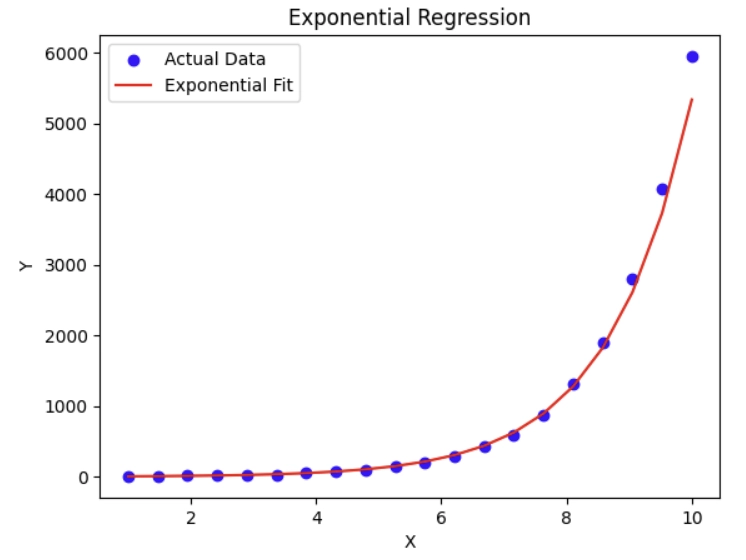
        파란 점: 실제 데이터 / 빨간 곡선: 모델이 예측한 회귀선
- 적합한 상황
    - 값이 시간에 따라 **지수적으로 증가하거나 감소**하는 경우 적합
    - 기술 발전, 투자 수익률 증가 등

## 3. 로그 회귀모델 (log regression model)
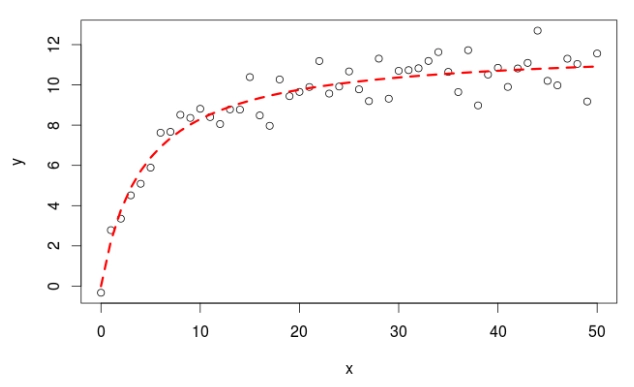
- 종속 변수와 독립 변수 간의 관계가 로그 함수를 통해 더 잘 표현될 때 사용할 수 있음
- 사용방법
    1. 독립 변수 X에 로그함수를 적용
    2. 선형 회귀를 적용  
    -> 이렇게 예측된 값은 Y이므로  예측값에 별도의 처리를 하지 않고 그대로 사용

<details>
<summary><strong>code</strong></summary>

`import numpy as np`  
`import matplotlib.pyplot as plt`  
`import statsmodels.api as sm`

- 로그함수 형태의 임의의 데이터 생성   
`np.random.seed(42)`  
`X = np.linspace(1, 10, 20).reshape(-1, 1)`  
`Y = 5 + 3 * np.log(X).flatten() + np.random.normal(0, 0.5, X.shape[0])` 

- 독립 변수 X에 자연 로그 변환  
`log_X = np.log(X)`  

- 회귀 모델 학습 (Y = a + b * log(X))  
`log_X_const = sm.add_constant(log_X)`   
`model = sm.OLS(Y, log_X_const).fit()`

- 예측값 계산  
`Y_pred = model.predict(log_X_const)`  

- 데이터 시각화  
`plt.scatter(X, Y, label="Actual Data", color="blue")`  
`plt.plot(X, Y_pred, label="Logarithmic Fit", color="red")`  
`plt.xlabel("X")`  
`plt.ylabel("Y")`  
`plt.title("Logarithmic Regression")`  
`plt.show()` 

</details>

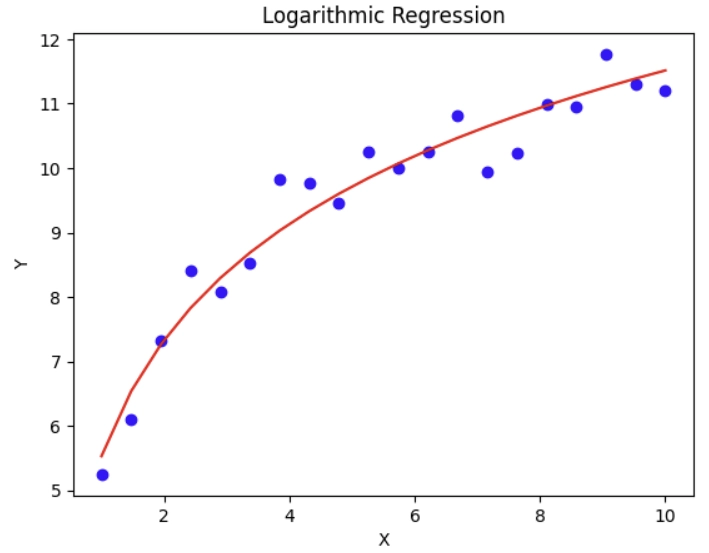
        파란 점: 실제 데이터 / 빨간 곡선: 모델이 예측한 회귀선
- 적합한 상황
    - 데이터가 초기에 빠르게 증가하고 점차 증가율이 줄어드는 패턴을 보일 때 효과적
    - 인구 성장, 감염병의 확산과 같이 **초기 빠른 증가 후 점진적 감소**를 보이는 데이터에 적합

## 4. 스플라인 회귀 (Spline Regression)
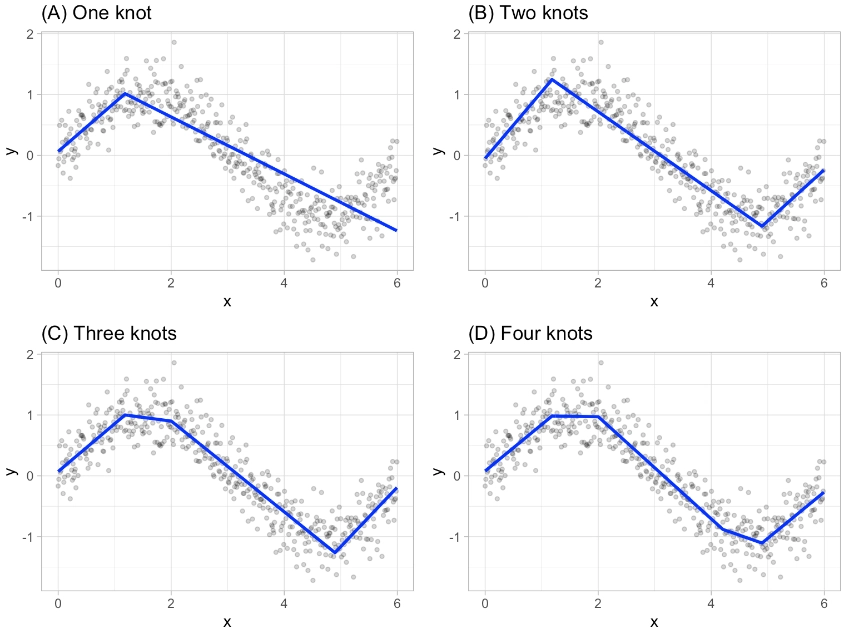
- 데이터를 구간별로 나누고 각 구간에서 다른 선형 또는 비선형 함수를 적용하여 예측하는 방식
- 사용 방법
    - 전체 데이터 범위를 여러 구간으로 나누고, 각 구간에 대해 별도의 회귀모델(선형, 다항 등) 적용
    - 구간 경계에서의 **연속성을 유지**하는 것이 중요
    - 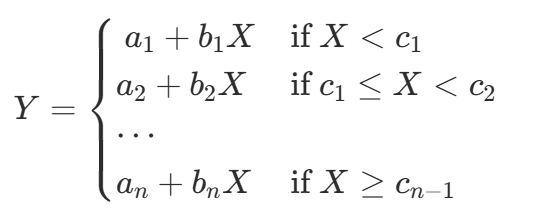

<details>
<summary><strong>code</strong></summary>

`import numpy as np`  
`import matplotlib.pyplot as plt`  
`import pandas as pd`  
`from sklearn.linear_model import LinearRegression`  
`from patsy import dmatrix`  
`import statsmodels.api as sm`


- 랜덤 데이터 생성  
`np.random.seed(42)`  
`X = np.linspace(0, 10, 100)`  
`Y = np.sin(X) + np.random.normal(0, 0.2, size=X.shape)`  

- X의 데이터에 스플라인 함수를 적용하여 새로운 데이터 X_spline을 만들고, 이 새로운 데이터로 선형 회귀를 진행하는 방식  
`X_spline = dmatrix("bs(X, df=5, degree=3, include_intercept=False)", {"X": X}, return_type='dataframe')`  
    - X: 데이터
    - df: 나눌 구간의 수+1 (df=5라면 4개의구간으로 구분합니다)
    - degree: 사용할 회귀 모델의 차수 (degree=1이면 선형회귀, degree=2면 2차 다항 회귀)
    - include_intercept=False: 절편 제거(필요하면 True로)
    - return_type='dataframe': dataframe 형식으로 반환  

    `model_spline = sm.OLS(Y, X_spline).fit()`  
    `Y_pred_spline = model_spline.predict(X_spline)`

- 시각화  
`plt.scatter(X, Y, label="Actual Data", color="blue", alpha=0.5)`  
`plt.plot(X, Y_pred_spline, label="Cubic Spline Regression", color="red")`  
`plt.xlabel("X")`  
`plt.ylabel("Y")`  
`plt.legend()`  
`plt.title("Cubic Spline Regression Fit")`    
`plt.show()`  

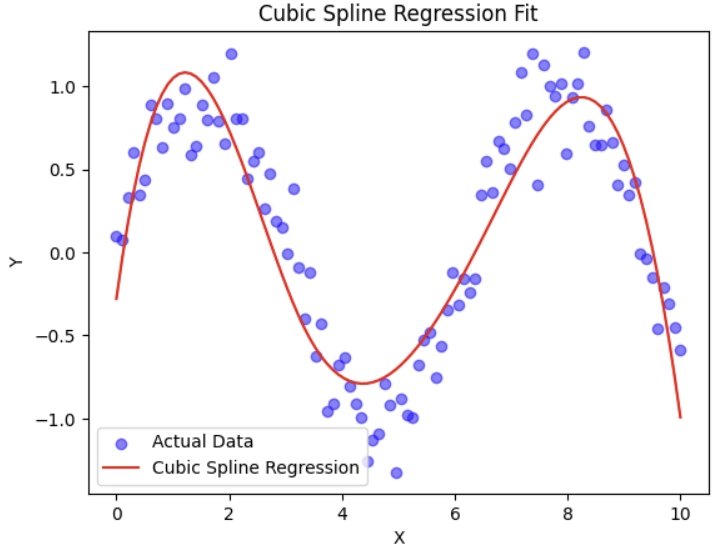

</details>

- 적합한 상황
    - 데이터 패턴이 여러 구간에서 서로 다르게 나타날 때 유용
    - 계절에 따라 판매량이 변화하는 소매 데이터 분석 등에서 적합